In [1]:
import wandb
from collections import defaultdict
import math
from matplotlib import pyplot as plt
import numpy as np

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs("huzican/div")  
for run in runs:
    print(f"名称: {run.name}, ID: {run.id}")

名称: llama_equ_correct_0.1_40step, ID: bne107la
名称: llama_equ_correct_0.1_40step, ID: c29gmav2
名称: qwen-math7B_belu0.01_correct, ID: y71x2zy3
名称: qwen-math1.5B_equ_100step, ID: nehn5fdn
名称: qwen-math1.5B_belu0.01_correct_clip0.2_0.28, ID: 63eghf69
名称: qwen-math1.5B_equ_40step, ID: 0rd5sdaw
名称: qwen-math7B_belu0.01_correct_clip0.2_0.28, ID: fl6nuqr5
名称: qwen-math1.5B_belu0.01_correct_clip0.2_0.28, ID: 7rs04969
名称: entropy_mechanism_clip_cov, ID: w86ul0kp
名称: qwen-math1.5B_belu0.01_correct_clip0.2_0.28, ID: wxpuba5l
名称: 1000tokens_belu0.01_correct_clip0.2_0.28, ID: 4eotdrrd
名称: qwen_math1.5B_baseline_clip0.2_0.28, ID: f00d368m
名称: llama_equ_correct_40step, ID: cgfr1bo1
名称: entropy_mechanism_kl_cov, ID: f7ognxtb
名称: qwen_math1.5B_belu0.01_correct_clip0.2_0.28, ID: 7wvpbofv
名称: 500token_belu0.01_correct_clip0.2_0.28, ID: 2awprc22
名称: baseline_passk_training, ID: 8fc5jxsw
名称: baseline_passk_training, ID: mf7myyzk
名称: pos_neg_belu0.01_correct_clip0.2_0.28, ID: gsicq6d1
名称: base_pos_neg_belu0.

In [4]:
run_names = ["huzican/div/u8wdkyeb", "huzican/div/rot5lg12", "huzican/div/6hnowqi3"]
legends = ["filter_high_equ_div", "filter_low_equ_div","embedding_high_div"]
benchmarks = ["olympiad_bench","minerva", "math", "amc", "aime25", "aime"]
run_results = {}
for idx, run_name in enumerate(run_names):
    run = api.run(run_name)
    scores = defaultdict(list)
    # print(scores)
    for i, row in run.history().iterrows():
        # print(row['val/test_score/aime'])
        # print(row['val/test_score/math'])
        for benchmark in benchmarks:
            path = "val/test_score/"+benchmark
            if not math.isnan(row[path]):
                scores[benchmark].append(row[path])
    print("*******************")
    print(scores)
    run_results[legends[idx]] = scores
print("#######################")
print(run_results)

*******************
defaultdict(<class 'list'>, {'olympiad_bench': [0.237741456166419, 0.2867756315007429, 0.3016344725111441, 0.3164933135215453, 0.34175334323922735, 0.3462109955423477, 0.36701337295690933, 0.38930163447251115, 0.36701337295690933, 0.3818722139673105, 0.3952451708766716, 0.38781575037147104, 0.4234769687964339, 0.4115898959881129, 0.4160475482912333, 0.42050520059435365, 0.413075780089153, 0.4175334323922734, 0.4294205052005943, 0.4145616641901932, 0.4234769687964339, 0.4234769687964339, 0.42050520059435365, 0.42199108469539376, 0.40713224368499257, 0.42199108469539376, 0.4279346210995542, 0.4160475482912333, 0.4160475482912333, 0.4338781575037147, 0.4264487369985141, 0.42199108469539376, 0.4338781575037147, 0.4145616641901932, 0.45022288261515603, 0.43536404160475484, 0.4487369985141159, 0.4279346210995542, 0.4264487369985141, 0.45022288261515603, 0.45170876671619614], 'minerva': [0.16176470588235295, 0.23897058823529413, 0.2426470588235294, 0.25735294117647056, 0.2

In [5]:
def smooth(y, radius, mode='two_sided', valid_only=False):
    assert mode in ('two_sided', 'causal')
    if len(y) < 2*radius+1:
        return np.ones_like(y) * y.mean()
    elif mode == 'two_sided':
        convkernel = np.ones(2 * radius+1)
        out = np.convolve(y, convkernel,mode='same') / np.convolve(np.ones_like(y), convkernel, mode='same')
        if valid_only:
            out[:radius] = out[-radius:] = np.nan
    elif mode == 'causal':
        convkernel = np.ones(radius)
        out = np.convolve(y, convkernel,mode='full') / np.convolve(np.ones_like(y), convkernel, mode='full')
        out = out[:-radius+1]
        if valid_only:
            out[:radius] = np.nan
    return out

<Figure size 8000x3200 with 0 Axes>

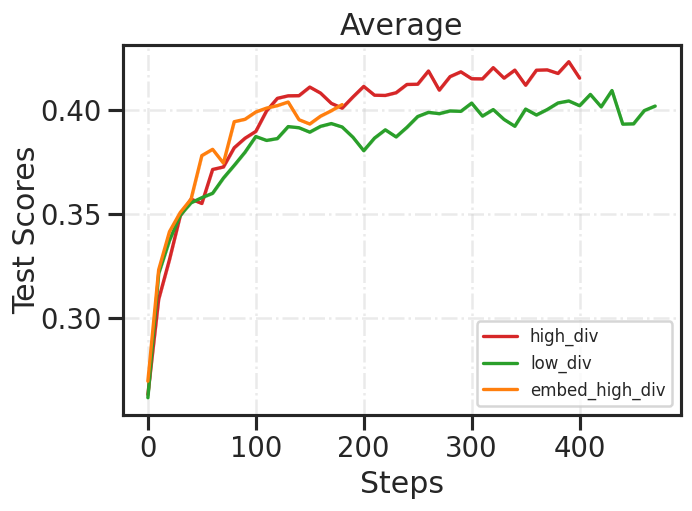

In [6]:
# env_names = ["olympiad_bench","minerva", "math", "amc", "aime25", "aime","average"]
## plot average
color = ['#D62728', '#2A9F2A', '#FF7F0E','#1B75B4','#9467BD','#7F7F7F','#E377C2']
label = ["high_div", "low_div","embed_high_div"]

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
sns.set_context('talk')

fig = plt.figure(figsize=(20, 8), dpi=400)
Grid = plt.GridSpec(2, 3, wspace=0.2, hspace=0.4)
plt.rcParams.update({'font.size': 15})

fig=plt.figure(figsize=(6, 4),dpi=120)
plt.title("Average")

for index, alg in enumerate(legends):
    group_data = []
    for benchmark in benchmarks:
        data = np.array(run_results[alg][benchmark])
        # data = smooth(data, radius=2)
        group_data.append(data)
        
    group_data = np.array(group_data)
    
    x_step = np.tile(np.array(range(group_data.shape[1]))*10, group_data.shape[0])
    group_data = np.tile(group_data.mean(axis=0),group_data.shape[0])
    # x_step = np.array(range(group_data.shape[1]))
    ax = sns.lineplot(x=x_step, y=group_data.flatten(),label=label[index], color=color[index], linewidth=2) 

plt.grid(True,linestyle='-.',alpha=0.4)
plt.legend(fontsize = 10,loc='lower right')
plt.ylabel('Test Scores', labelpad=-0.5)
plt.xlabel('Steps')
plt.show()

In [7]:
run_names = ["huzican/div/dq4cz2od", "huzican/div/qgztz1vu"]
legends = ["div","baseline"]
benchmarks = ["olympiad_bench","minerva", "math", "amc", "aime25", "aime"]
run_results = {}
for idx, run_name in enumerate(run_names):
    run = api.run(run_name)
    scores = defaultdict(list)
    # print(scores)
    for i, row in run.history().iterrows():
        # print(row['val/test_score/aime'])
        # print(row['val/test_score/math'])
        for benchmark in benchmarks:
            path = "val/test_score/"+benchmark
            if not math.isnan(row[path]):
                scores[benchmark].append(row[path])
    # print("*******************")
    # print(scores)
    run_results[legends[idx]] = scores
# print("#######################")
# print(run_results)

<Figure size 8000x3200 with 0 Axes>

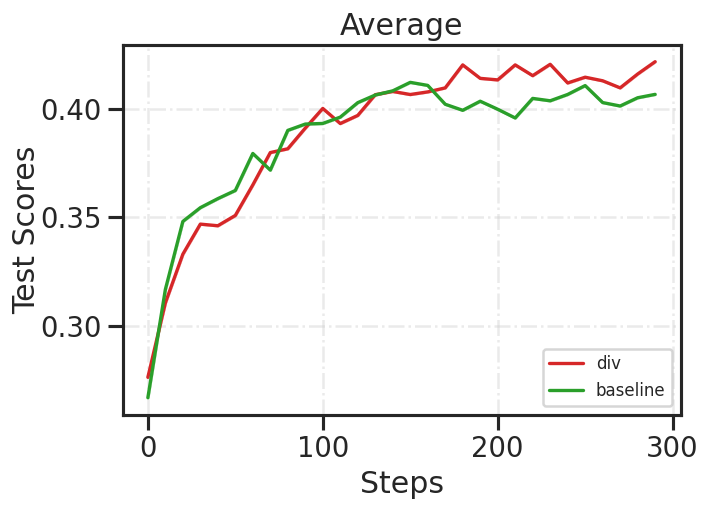

In [8]:
color = ['#D62728', '#2A9F2A', '#FF7F0E','#1B75B4','#9467BD','#7F7F7F','#E377C2']
label = ["div", "baseline"]

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('ticks')
sns.set_context('talk')

fig = plt.figure(figsize=(20, 8), dpi=400)
Grid = plt.GridSpec(2, 3, wspace=0.2, hspace=0.4)
plt.rcParams.update({'font.size': 15})

fig=plt.figure(figsize=(6, 4),dpi=120)
plt.title("Average")

for index, alg in enumerate(legends):
    group_data = []
    for benchmark in benchmarks:
        data = np.array(run_results[alg][benchmark])
        # data = smooth(data, radius=2)
        group_data.append(data[:30])
        
    group_data = np.array(group_data)
    
    x_step = np.tile(np.array(range(group_data.shape[1]))*10, group_data.shape[0])
    group_data = np.tile(group_data.mean(axis=0),group_data.shape[0])
    # x_step = np.array(range(group_data.shape[1]))
    ax = sns.lineplot(x=x_step, y=group_data.flatten(),label=label[index], color=color[index], linewidth=2) 

plt.grid(True,linestyle='-.',alpha=0.4)
plt.legend(fontsize = 10,loc='lower right')
plt.ylabel('Test Scores', labelpad=-0.5)
plt.xlabel('Steps')
plt.show()